# EKDIST - end-to-end single-channel analysis

This notebook walks through the complete EKDIST analysis pipeline using the
bundled `AChsim.scn` simulated acetylcholine-receptor record:

1. Load SCN file and impose dead-time resolution
2. Check temporal stationarity (runs test, Cox-Lewis test)
3. Fit open-period distribution (exponential mixture MLE)
4. Fit shut-period distribution and calculate critical times
5. Group openings into bursts
6. Estimate global and burst-level Popen with bootstrap CIs
7. Fit burst-length distribution

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from ekdist import (
    SingleChannelRecord,
    ExponentialPDF,
    GaussianMixturePDF,
    Bursts,
    Tcrit,
    ApproximateSD,
    LikelihoodIntervals,
    runs_test,
    cox_lewis_test,
    serial_correlation,
    open_shut_correlation,
    global_popen,
    burst_popen,
    plots,
)

---
## 1. Load SCN file and impose resolution

In [2]:
rec = SingleChannelRecord.from_scn("tests/AChsim.scn")
print(rec)

SCN file: AChsim.scn
  Raw intervals   : 13948
  Resolution (µs) : 0.0
  Resolved        : 13945
  Periods         : 13945

  Open periods  n=6973
    mean ± SD = 0.4284 ± 0.6393 ms
    range     = 0.0100 – 7.0957 ms
  Shut periods  n=6972
    mean ± SD = 1101.5951 ± 1566.3548 ms
    range     = 0.0100 – 14774.8311 ms


In [3]:
# Impose 30 uss dead-time resolution
rec.tres = 30e-6
print(rec)

SCN file: AChsim.scn
  Raw intervals   : 13948
  Resolution (µs) : 30.0
  Resolved        : 8565
  Periods         : 8565

  Open periods  n=4283
    mean ± SD = 0.6988 ± 1.1867 ms
    range     = 0.0300 – 12.2463 ms
  Shut periods  n=4282
    mean ± SD = 1793.6281 ± 2136.3319 ms
    range     = 0.0300 – 18486.7947 ms


In [4]:
opens = rec.periods.open_intervals
shuts = rec.periods.shut_intervals

print(f"Resolved open periods : {len(opens):,}")
print(f"Resolved shut periods : {len(shuts):,}")
print(f"Mean open period      : {np.mean(opens)*1e3:.3f} ms")
print(f"Mean shut period      : {np.mean(shuts)*1e3:.3f} ms")

Resolved open periods : 4,283
Resolved shut periods : 4,282
Mean open period      : 0.699 ms
Mean shut period      : 1793.628 ms


---
## 2. Stationarity tests

Before fitting, check that the recording is stationary - i.e. that the
channel kinetics did not drift or rundown during the experiment.

In [5]:
print("=== Open periods ===")
print(runs_test(opens))
print()
print(cox_lewis_test(opens))

=== Open periods ===
Runs test (n=4283)
  statistic = -6.9693
  p-value   = 0.0000
  Non-stationary (p < 0.05): evidence of trend or systematic change.

Cox-Lewis trend test (n=4283)
  statistic = -1.0821
  p-value   = 0.2792
  Stationary (p >= 0.05): no significant trend detected.


In [6]:
print("=== Shut periods ===")
print(runs_test(shuts))
print()
print(cox_lewis_test(shuts))

=== Shut periods ===
Runs test (n=4282)
  statistic = -3.3318
  p-value   = 0.0009
  Non-stationary (p < 0.05): evidence of trend or systematic change.

Cox-Lewis trend test (n=4282)
  statistic = 2.2957
  p-value   = 0.0217
  Non-stationary (p < 0.05): Intervals getting shorter (activity increasing).


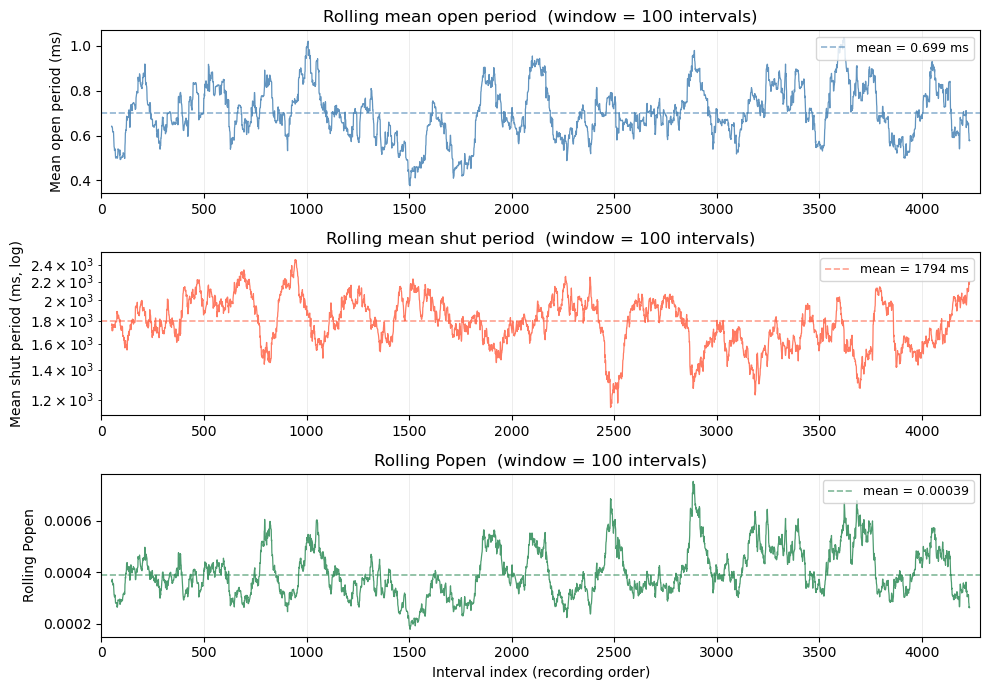

In [7]:
fig = plots.stability_rolling(opens, shuts, window=100)
plt.tight_layout()

---
## 3. Open-period distribution

Fit a mixture of exponential components by maximum likelihood.  The likelihood
is truncated at `tres` to correct for missed events.

In [8]:
# Three-component exponential mixture - initial time constants in seconds
open_pdf = ExponentialPDF([1e-4, 1e-3, 1e-2])
open_pdf.fit(opens, tres=rec.tres)
print(open_pdf)

In [9]:
# Parameter uncertainty
asd_open = ApproximateSD(open_pdf.theta, open_pdf.LL, opens)
print("Approximate SDs:", asd_open.sd)
print("Correlations:")
print(np.round(asd_open.correlations, 3))

Negative diagonal elements in covariance matrix; Hessian may not be positive-definite at this point


Approximate SDs: [9.91217199e-07 7.87252945e-06 5.00140818e-05 9.15376369e-03
 6.30549218e-03]
Correlations:
[[ 1.     0.584  0.096  0.227 -0.578]
 [ 0.584  1.     0.384  0.115  0.09 ]
 [ 0.096  0.384  1.     0.258  0.156]
 [ 0.227  0.115  0.258 -1.     1.527]
 [-0.578  0.09   0.156  1.527 -1.   ]]


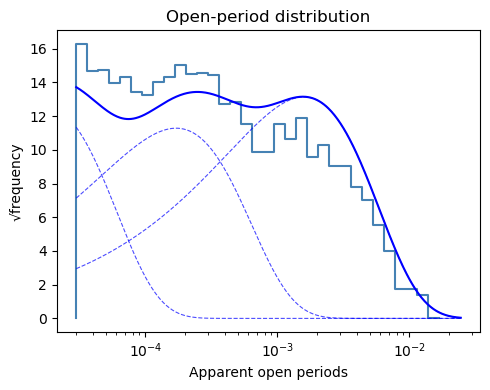

In [10]:
fig = plots.histogram_dwell_times(
    opens, tres=rec.tres, pdf=open_pdf,
    xlabel="Apparent open periods",
    title="Open-period distribution",
)
plt.tight_layout()

---
## 4. Shut-period distribution and critical time

The critical shut time (tcrit) separates brief within-burst closures from long
between-burst gaps.

In [11]:
shut_pdf = ExponentialPDF([2e-5, 2e-3, 2.0])
shut_pdf.fit(shuts, tres=rec.tres)
print(shut_pdf)

In [12]:
# Critical times between all adjacent pairs of components
tc = shut_pdf.get_tcrits(verbose=True)

Equal % misclassified (DC criterion)
Components 1–2  tcrit = 0.08862 ms
  % misclassified: fast = 0.455  slow = 0.455
  # misclassified (per 100): fast = 0.2395  slow = 0.2155
  Total misclassified (per 100) = 0.455
Components 2–3  tcrit = 2.008 ms
  % misclassified: fast = 0.09181  slow = 0.09181
  # misclassified (per 100): fast = 0.04973  slow = 0.04208
  Total misclassified (per 100) = 0.09181

Equal # misclassified (Clapham & Neher criterion)
Components 1–2  tcrit = 0.0901 ms
  % misclassified: fast = 0.4157  slow = 0.4621
  # misclassified (per 100): fast = 0.2188  slow = 0.2188
  Total misclassified (per 100) = 0.4377
Components 2–3  tcrit = 2.084 ms
  % misclassified: fast = 0.08063  slow = 0.09529
  # misclassified (per 100): fast = 0.04368  slow = 0.04368
  Total misclassified (per 100) = 0.08735

Minimum total # misclassified (Jackson et al criterion)
Components 1–2  tcrit = 0.1202 ms
  % misclassified: fast = 0.06672  slow = 0.6012
  # misclassified (per 100): fast = 0.0351

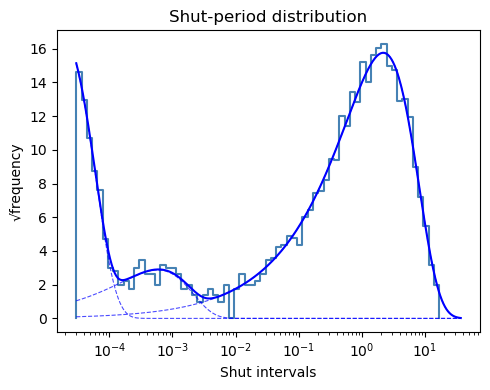

In [13]:
fig = plots.histogram_dwell_times(
    shuts, tres=rec.tres, pdf=shut_pdf,
    xlabel="Shut intervals",
    title="Shut-period distribution",
)
plt.tight_layout()

---
## 5. Burst analysis

Group openings into bursts using the DC (equal % misclassified) critical time
between the 2nd and 3rd shut components.

In [14]:
# Use tcrit between components 2 and 3 (index 1) from the DC criterion
tcrit_DC = shut_pdf.tcrits["DC"][1]
print(f"tcrit (DC, components 2-3) = {tcrit_DC*1e3:.4f} ms")

bursts = Bursts.from_periods(rec.periods, tcrit=tcrit_DC)
print(bursts)

tcrit (DC, components 2-3) = 2.0080 ms
Bursts(tcrit=2.008 ms, n=3520,
  mean_duration   = 0.8770 ms
  mean_Popen      = 0.9766
  mean_n_openings = 1.22)


In [15]:
# Burst-length distribution
burst_lengths = bursts.list_duration()

burst_len_pdf = ExponentialPDF([4e-5, 3e-4, 1e-2])
burst_len_pdf.fit(np.array(burst_lengths), tres=rec.tres)
print(burst_len_pdf)

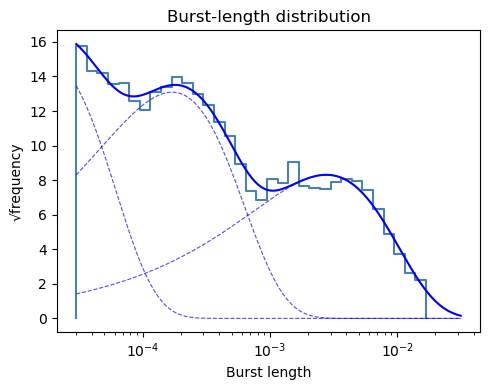

In [16]:
fig = plots.histogram_dwell_times(
    np.array(burst_lengths), tres=rec.tres, pdf=burst_len_pdf,
    xlabel="Burst length",
    title="Burst-length distribution",
)
plt.tight_layout()

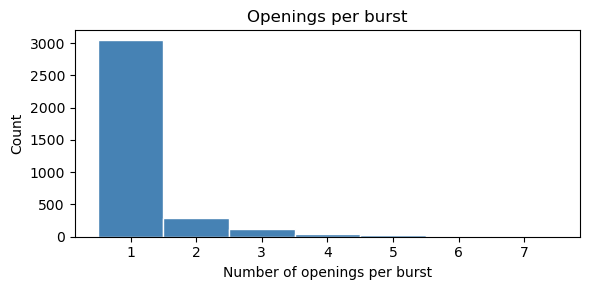

In [17]:
# Number of openings per burst
n_openings = bursts.list_n_openings()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(n_openings, bins=range(1, max(n_openings) + 2), align="left",
        color="steelblue", edgecolor="white")
ax.set_xlabel("Number of openings per burst")
ax.set_ylabel("Count")
ax.set_title("Openings per burst")
plt.tight_layout()

---
## 6. Open probability

Two Popen estimates with 95% bootstrap confidence intervals:

- **Global Popen** - total open time / total resolved time
- **Burst Popen** - mean per-burst Popen (excluding last opening of each burst)

In [18]:
rng = np.random.default_rng(42)

gp = global_popen(rec, n_bootstrap=2000, rng=rng)
print("Global Popen:")
print(gp)

Global Popen:
Popen = 0.000390  [95% CI: 0.000366 – 0.000414]  (n_bootstrap=2000)


In [19]:
bp = burst_popen(bursts, n_bootstrap=2000, rng=rng)
print("Burst Popen:")
print(bp)

Burst Popen:
Popen = 0.976559  [95% CI: 0.972725 – 0.980312]  (n_bootstrap=2000)


---
## 7. Correlation analysis

Two classical diagnostics for testing whether a channel's kinetics are
consistent with a simple Markov model:

- **Serial autocorrelation** r₁ … rₖ between successive intervals separated
  by lag k. Under a memoryless (Markov) model all rₖ = 0; significant positive
  autocorrelation means long and short openings tend to cluster together.
- **Open-shut interval correlation** — Pearson r between each open interval
  and the shut interval that immediately follows it. Non-zero r is incompatible
  with a simple two-state model and indicates that the channel carries memory
  of its previous state between openings and closings.

Both use Fisher Z-transforms for significance testing, matching the
Colquhoun lab Fortran CORCAL routine.

### 7a. Serial autocorrelation of open and shut periods

Compute lagged autocorrelation for lags 1–20. A two-component exponential
channel (two open states, two shut states) typically shows positive r₁ for
both open and shut times.

In [20]:
# Lags 1-20; exclude extreme outliers (top 0.1%) to stabilise pooling
open_hi  = np.quantile(opens, 0.999)
shut_hi  = np.quantile(shuts, 0.999)

sc_open = serial_correlation(opens, max_lag=20, outlier_limit=open_hi)
sc_shut = serial_correlation(shuts, max_lag=20, outlier_limit=shut_hi)

print("--- Open periods ---")
print(sc_open.summary())
print()
print("--- Shut periods ---")
print(sc_shut.summary())

--- Open periods ---
Serial autocorrelation  (n=4278, outlier limit=0.009476)
  Lag           r     deviate   segments        df
    1      0.0204      1.3339          6      4254
    2      0.0093      0.6047          6      4248
    3      0.0017      0.1133          6      4242
    4      0.0005      0.0302          6      4236
    5      0.0043      0.2821          6      4230
    6     -0.0004     -0.0291          6      4224
    7     -0.0046     -0.2966          6      4218
    8     -0.0017     -0.1074          6      4212
    9     -0.0043     -0.2801          6      4206
   10     -0.0035     -0.2279          6      4200
   11     -0.0056     -0.3608          6      4194
   12     -0.0038     -0.2452          6      4188
   13     -0.0028     -0.1782          6      4182
   14     -0.0047     -0.3063          6      4176
   15      0.0043      0.2805          6      4170
   16     -0.0036     -0.2341          6      4164
   17      0.0004      0.0288          6      4158
   1

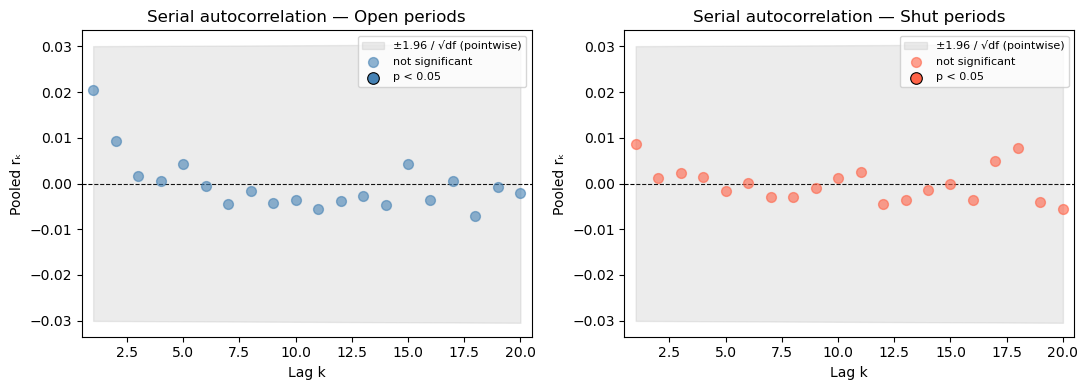

In [21]:
fig = plots.plot_serial_correlation(
    sc_open, sc_shut,
    labels=["Open periods", "Shut periods"],
    colors=["steelblue", "tomato"],
)
plt.tight_layout()

### 7b. Open-shut interval correlation

Pair each open interval with the shut interval immediately following it.
The scatter plot shows the joint distribution; the Pearson r and Fisher Z
normal deviate quantify the linear dependence.

In [22]:
# Pair open[i] with the shut interval that follows it: shuts[i+1]
# (shuts[0] is the initial gap before the first opening; skip it)
n_pairs = min(len(opens), len(shuts) - 1)
op_paired = opens[:n_pairs]           # open[0], open[1], …
sh_paired = shuts[1 : n_pairs + 1]    # shut after open[0], open[1], …

osc = open_shut_correlation(op_paired, sh_paired)
print(osc)

Open-shut interval correlation (n=4281)
  r           = -0.0433
  normal dev. = -2.8368  (df=4278)
  p-value     = 0.0046
  Significant negative open-shut correlation (p < 0.05): inconsistent with a simple two-state model.


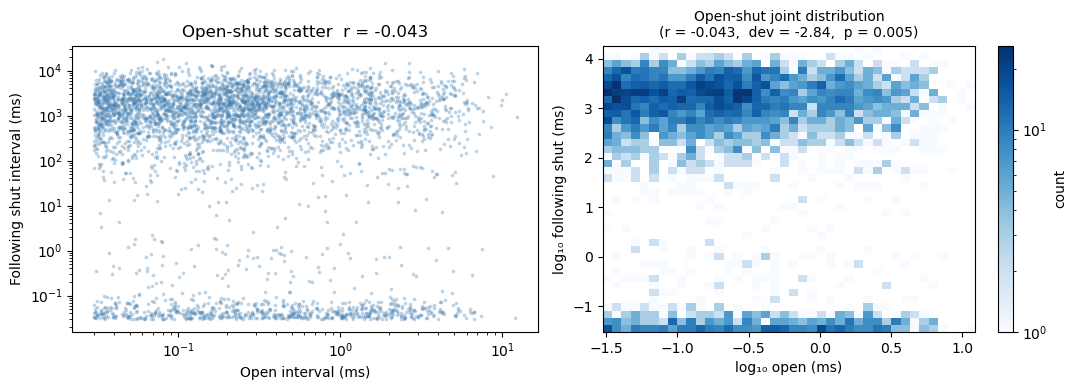

In [23]:
fig = plots.plot_open_shut_scatter(op_paired, sh_paired, result=osc)
plt.tight_layout()